# Prueba Técnica — Analista de Datos
**Fuente:** Sistema Único de Información (SUI) — SSPD

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')
print('Entorno activo, listo para desarrollar.')

Entorno activo, listo para desarrollar.


# Parte 1 — Carga y exploración inicial
## Bitácora de carga
- **Fuente:** SUI — SSPD, archivo descargado manualmente en formato Excel (.xlsx)
- **Método:** `pd.read_excel()` sobre cada hoja del archivo
- **Hojas:** `Toneladas a Abril 2026` (datos principales) y `Publicación reversiones` (auditoría)

In [2]:
archivo_sui = '../datos/Toneladas-aprovechadas-abril-2026.xlsx'

df = pd.read_excel(archivo_sui, sheet_name='Toneladas a Abril 2026')
df_rev = pd.read_excel(archivo_sui, sheet_name='Publicación reversiones')

print('Principal  :', df.shape)
print('Reversiones:', df_rev.shape)
print('\nColumnas principales:')
print(df.columns.tolist())

Principal  : (126304, 12)
Reversiones: (26017, 10)

Columnas principales:
['ID EMPRESA', 'EMPRESA', 'AÑO', 'PERIODO', 'DEPARTAMENTO ORIGEN', 'MUNICIPIO ORIGEN', 'NUECA', 'Origen de los Residuos', 'TONELADAS APROVECHADAS', 'FECHA', 'FECHA APROBACION RUPS', 'MECANISMO DE CARGUE']


### Exploración inicial de los datos

Se realizó una revisión preliminar del conjunto de datos para comprender su estructura, verificar los tipos de variables, identificar valores faltantes y obtener un resumen estadístico general. Esta etapa permitió evaluar la calidad de la información y detectar posibles ajustes necesarios antes de iniciar el análisis.

In [3]:
df.head()

,ID EMPRESA,EMPRESA,AÑO,PERIODO,DEPARTAMENTO ORIGEN,MUNICIPIO ORIGEN,NUECA,Origen de los Residuos,TONELADAS APROVECHADAS,FECHA,FECHA APROBACION RUPS,MECANISMO DE CARGUE
0,78,EMPRESA DE SERVICIOS DE EL RETIRO - RETIRAR S....,2019,MAYO,ANTIOQUIA,RETIRO,2368705607,NaN,31.1662,2021-11-20,2006-12-20,CM
1,78,EMPRESA DE SERVICIOS DE EL RETIRO - RETIRAR S....,2019,JUNIO,ANTIOQUIA,RETIRO,2368705607,NaN,16.5969,2021-11-20,2006-12-20,CM
2,78,EMPRESA DE SERVICIOS DE EL RETIRO - RETIRAR S....,2019,JULIO,ANTIOQUIA,RETIRO,2368705607,NaN,31.3674,2021-11-20,2006-12-20,CM
3,78,EMPRESA DE SERVICIOS DE EL RETIRO - RETIRAR S....,2023,JULIO,ANTIOQUIA,RETIRO,2368705607,Rural,Publicación Aplazada,2023-08-03,2006-12-20,APP
4,78,EMPRESA DE SERVICIOS DE EL RETIRO - RETIRAR S....,2023,JULIO,ANTIOQUIA,RETIRO,2368705607,Urbano,Publicación Aplazada,2023-08-03,2006-12-20,APP


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 126304 entries, 0 to 126303
Data columns (total 12 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   ID EMPRESA              126304 non-null  int64         
 1   EMPRESA                 126304 non-null  str           
 2   AÑO                     126304 non-null  int64         
 3   PERIODO                 126304 non-null  str           
 4   DEPARTAMENTO ORIGEN     126304 non-null  str           
 5   MUNICIPIO ORIGEN        126304 non-null  str           
 6   NUECA                   126304 non-null  int64         
 7   Origen de los Residuos  76179 non-null   str           
 8   TONELADAS APROVECHADAS  126304 non-null  object        
 9   FECHA                   126304 non-null  datetime64[us]
 10  FECHA APROBACION RUPS   126304 non-null  datetime64[us]
 11  MECANISMO DE CARGUE     126304 non-null  str           
dtypes: datetime64[us](2), int64(3), object(1)

In [5]:
df.isnull().sum()

ID EMPRESA                    0
EMPRESA                       0
AÑO                           0
PERIODO                       0
DEPARTAMENTO ORIGEN           0
MUNICIPIO ORIGEN              0
NUECA                         0
Origen de los Residuos    50125
TONELADAS APROVECHADAS        0
FECHA                         0
FECHA APROBACION RUPS         0
MECANISMO DE CARGUE           0
dtype: int64

In [6]:
df.describe(include='all')

,ID EMPRESA,EMPRESA,AÑO,PERIODO,DEPARTAMENTO ORIGEN,MUNICIPIO ORIGEN,NUECA,Origen de los Residuos,TONELADAS APROVECHADAS,FECHA,FECHA APROBACION RUPS,MECANISMO DE CARGUE
count,126304.000000,126304,126304.000000,126304,126304,126304,1.263040e+05,76179,126304,126304,126304,126304
unique,NaN,1263,NaN,12,30,320,NaN,2,97287,NaN,NaN,2
top,NaN,INTERASEO S.A.S E.S.P.,NaN,ABRIL,"BOGOTA, D.C.","BOGOTA, D.C.",NaN,Urbano,Publicación Aplazada,NaN,NaN,APP
freq,NaN,1995,NaN,11236,57200,57200,NaN,72746,10720,NaN,NaN,112801
mean,43158.324139,NaN,2022.227325,NaN,NaN,NaN,1.822971e+09,NaN,NaN,2022-10-21 23:05:32.227007,2018-12-18 15:46:20.035469,NaN
min,78.000000,NaN,2016.000000,NaN,NaN,NaN,2.422470e+08,NaN,NaN,2016-11-08 00:00:00,2005-11-25 00:00:00,NaN
25%,36878.000000,NaN,2021.000000,NaN,NaN,NaN,9.986085e+08,NaN,NaN,2021-02-03 00:00:00,2017-04-07 00:00:00,NaN
50%,41276.000000,NaN,2022.000000,NaN,NaN,NaN,1.532711e+09,NaN,NaN,2023-01-02 00:00:00,2018-11-25 00:00:00,NaN
75%,49088.000000,NaN,2024.000000,NaN,NaN,NaN,2.488811e+09,NaN,NaN,2024-10-03 00:00:00,2020-10-09 00:00:00,NaN
max,160205.000000,NaN,2026.000000,NaN,NaN,NaN,5.151811e+09,NaN,NaN,2026-05-06 00:00:00,2026-02-09 00:00:00,NaN


# Parte 2 — Procesamiento
## 2.1 Limpieza y calidad de datos

In [7]:
# Respaldo
df_raw = df.copy()

# Eliminar columna vacía
df.drop(columns=[c for c in df.columns if 'Unnamed' in str(c)], inplace=True)

# Normalizar texto
cols_texto = ['EMPRESA','DEPARTAMENTO ORIGEN','MUNICIPIO ORIGEN','Origen de los Residuos','MECANISMO DE CARGUE']
for col in cols_texto:
    if col in df.columns:
        df[col] = df[col].astype(str).str.upper().str.strip()

print('Columnas tras limpieza:', df.columns.tolist())

Columnas tras limpieza: ['ID EMPRESA', 'EMPRESA', 'AÑO', 'PERIODO', 'DEPARTAMENTO ORIGEN', 'MUNICIPIO ORIGEN', 'NUECA', 'Origen de los Residuos', 'TONELADAS APROVECHADAS', 'FECHA', 'FECHA APROBACION RUPS', 'MECANISMO DE CARGUE']


In [8]:
# Clasificar estado del reporte
def clasificar_estado(valor):
    try:
        float(str(valor).replace(',', '.'))
        return 'CERTIFICADO'
    except:
        v = str(valor).upper()
        if 'APLAZADA' in v:    return 'PUBLICACION APLAZADA'
        if 'VERIFICACION' in v: return 'SUJETO A VERIFICACION'
        return v

df['ESTADO_REPORTE'] = df['TONELADAS APROVECHADAS'].apply(clasificar_estado)
df['ESTADO_REPORTE'].value_counts()

ESTADO_REPORTE
CERTIFICADO               115557
PUBLICACION APLAZADA       10720
SUJETO A VERIFICACIÓN*        27
Name: count, dtype: int64

In [9]:
# Dataset analítico: solo registros certificados
df_clean = df[df['ESTADO_REPORTE'] == 'CERTIFICADO'].copy()

# Toneladas a numérico
df_clean['TONELADAS_NUM'] = pd.to_numeric(
    df_clean['TONELADAS APROVECHADAS'].astype(str).str.replace(',', '.'),
    errors='coerce'
)

# Mes a número
meses = {'ENERO':1,'FEBRERO':2,'MARZO':3,'ABRIL':4,'MAYO':5,'JUNIO':6,
         'JULIO':7,'AGOSTO':8,'SEPTIEMBRE':9,'OCTUBRE':10,'NOVIEMBRE':11,'DICIEMBRE':12}
df_clean['MES_NUMERO'] = df_clean['PERIODO'].map(meses)

# Fechas
for col in ['FECHA','FECHA APROBACION RUPS']:
    if col in df_clean.columns:
        df_clean[col] = pd.to_datetime(df_clean[col], dayfirst=True, errors='coerce')

# Nulos en origen
df_clean['Origen de los Residuos'] = df_clean['Origen de los Residuos'].replace('NAN', np.nan).fillna('SIN CLASIFICAR')

print('Registros certificados:', len(df_clean))

Registros certificados: 115557


In [10]:
# Calidad de datos
calidad = pd.DataFrame({
    'Tipo': df_clean.dtypes.astype(str),
    'Nulos': df_clean.isnull().sum(),
    '% Nulos': round(df_clean.isnull().sum() / len(df_clean) * 100, 2),
    'Únicos': df_clean.nunique()
})
calidad.sort_values('% Nulos', ascending=False)

,Tipo,Nulos,% Nulos,Únicos
ID EMPRESA,int64,0,0.0,1082
EMPRESA,str,0,0.0,1089
AÑO,int64,0,0.0,11
PERIODO,str,0,0.0,12
DEPARTAMENTO ORIGEN,str,0,0.0,30
MUNICIPIO ORIGEN,str,0,0.0,286
NUECA,int64,0,0.0,3509
Origen de los Residuos,str,0,0.0,3
TONELADAS APROVECHADAS,object,0,0.0,97285
FECHA,datetime64[us],0,0.0,1875


In [11]:
# Duplicados exactos
n_dup = df_clean.duplicated().sum()
print(f'Duplicados exactos: {n_dup}')
df_clean = df_clean.drop_duplicates()
print(f'Registros tras depuración: {len(df_clean)}')

Duplicados exactos: 7
Registros tras depuración: 115550


In [12]:
# Duplicados operativos
clave_op = ['ID EMPRESA','AÑO','PERIODO','MUNICIPIO ORIGEN','NUECA']
dup_op = df_clean[df_clean.duplicated(subset=clave_op, keep=False)]
print(f'Registros involucrados: {len(dup_op)}')
print(f'Grupos duplicados     : {dup_op[clave_op].drop_duplicates().shape[0]}')
print('Nota: diferencias en toneladas entre grupos — se conservan como registros válidos.')

Registros involucrados: 5981
Grupos duplicados     : 2990
Nota: diferencias en toneladas entre grupos — se conservan como registros válidos.


In [13]:
# Outliers por IQR
Q1 = df_clean['TONELADAS_NUM'].quantile(0.25)
Q3 = df_clean['TONELADAS_NUM'].quantile(0.75)
IQR = Q3 - Q1
lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR

df_clean['ES_OUTLIER'] = (
    (df_clean['TONELADAS_NUM'] < lim_inf) |
    (df_clean['TONELADAS_NUM'] > lim_sup)
)

n_out = df_clean['ES_OUTLIER'].sum()
print(f'Límite inferior : {lim_inf:,.2f}')
print(f'Límite superior : {lim_sup:,.2f}')
print(f'Outliers        : {n_out} ({round(n_out/len(df_clean)*100,2)}%)')
print('Los outliers se conservan — corresponden a operadores de gran escala.')

Límite inferior : -192.02
Límite superior : 393.34
Outliers        : 9388 (8.12%)
Los outliers se conservan — corresponden a operadores de gran escala.


## 2.2 Agrupación regional
Se usan las **5 regiones naturales de Colombia** (DANE): Caribe, Pacífico, Andina, Orinoquía y Amazonía. Este criterio es reconocido institucionalmente, facilita la comparación con estadísticas oficiales y permite identificar patrones de aprovechamiento por ecosistema y densidad poblacional.

In [14]:
region_map = {
    'ATLANTICO':'Caribe','BOLIVAR':'Caribe','CESAR':'Caribe','CORDOBA':'Caribe',
    'LA GUAJIRA':'Caribe','MAGDALENA':'Caribe','SUCRE':'Caribe','SAN ANDRES':'Caribe',
    'CHOCO':'Pacífico','VALLE DEL CAUCA':'Pacífico','CAUCA':'Pacífico','NARIÑO':'Pacífico',
    'ANTIOQUIA':'Andina','CALDAS':'Andina','RISARALDA':'Andina','QUINDIO':'Andina',
    'TOLIMA':'Andina','HUILA':'Andina','CUNDINAMARCA':'Andina','BOYACA':'Andina',
    'SANTANDER':'Andina','NORTE DE SANTANDER':'Andina','BOGOTA D.C.':'Andina',
    'META':'Orinoquía','CASANARE':'Orinoquía','ARAUCA':'Orinoquía','VICHADA':'Orinoquía',
    'AMAZONAS':'Amazonía','CAQUETA':'Amazonía','PUTUMAYO':'Amazonía',
    'GUAINIA':'Amazonía','GUAVIARE':'Amazonía','VAUPES':'Amazonía',
}

correcciones = {
    'NARINO':'Pacífico',
    'BOGOTA, D.C.':'Andina',
    'ARCHIPIELAGO DE SAN ANDRES, PROVIDENCIA Y SANTA CATALINA':'Caribe'
}

df_clean['REGION'] = df_clean['DEPARTAMENTO ORIGEN'].map(region_map)
df_clean['REGION'] = df_clean['REGION'].fillna(df_clean['DEPARTAMENTO ORIGEN'].map(correcciones))

print(f'Sin región asignada: {df_clean["REGION"].isnull().sum()}')
df_clean['REGION'].value_counts()

Sin región asignada: 0


REGION
Andina       87958
Caribe       12916
Pacífico      9730
Orinoquía     4655
Amazonía       291
Name: count, dtype: int64

## 2.3 Cuadre por categorías

In [15]:
pivot_depto  = df_clean.groupby(['AÑO','DEPARTAMENTO ORIGEN'])['TONELADAS_NUM'].sum().unstack().fillna(0)
pivot_origen = df_clean.groupby(['AÑO','Origen de los Residuos'])['TONELADAS_NUM'].sum().unstack().fillna(0)
pivot_region = df_clean.groupby(['AÑO','REGION'])['TONELADAS_NUM'].sum().unstack().fillna(0)
pivot_mes    = df_clean.groupby(['AÑO','MES_NUMERO'])['TONELADAS_NUM'].sum().unstack().fillna(0)

top20 = df_clean.groupby('EMPRESA')['TONELADAS_NUM'].sum().nlargest(20).index
pivot_empresa = df_clean[df_clean['EMPRESA'].isin(top20)].groupby(['AÑO','EMPRESA'])['TONELADAS_NUM'].sum().unstack().fillna(0)

print('Departamento:', pivot_depto.shape)
print('Origen      :', pivot_origen.shape)
print('Región      :', pivot_region.shape)
print('Empresa top20:', pivot_empresa.shape)
print('Mes         :', pivot_mes.shape)

Departamento: (11, 30)
Origen      : (11, 3)
Región      : (11, 5)
Empresa top20: (11, 20)
Mes         : (11, 12)


## 2.4 Análisis de reversiones

In [16]:
# Normalizar reversiones
for col in ['EMPRESA','DEPARTAMENTO ORIGEN','MUNICIPIO ORIGEN']:
    if col in df_rev.columns:
        df_rev[col] = df_rev[col].astype(str).str.upper().str.strip()

# Total por año
rev_año = df_rev.groupby('AÑO').size().reset_index(name='TOTAL_REVERSIONES')
print('Reversiones por año:')
print(rev_año.to_string(index=False))

Reversiones por año:
 AÑO  TOTAL_REVERSIONES
2019                900
2020               1702
2021               9217
2022               6095
2023               5004
2024               2411
2025                682
2026                  6


In [17]:
# Tasa de reversión por empresa
total_emp = df_clean.groupby('EMPRESA').size().rename('TOTAL_REPORTES')
rev_emp   = df_rev.groupby('EMPRESA').size().rename('REVERSIONES')

tasa_rev = pd.concat([total_emp, rev_emp], axis=1).fillna(0)
tasa_rev['TASA_%'] = round(tasa_rev['REVERSIONES'] / tasa_rev['TOTAL_REPORTES'] * 100, 2)

top10_rev = tasa_rev.sort_values('TASA_%', ascending=False).head(10)
print('Top 10 empresas con mayor tasa de reversión:')
print(top10_rev)

Top 10 empresas con mayor tasa de reversión:
                                                    TOTAL_REPORTES  \
EMPRESA                                                              
RECICLAJE Y AMBIENTE SANO                                      0.0   
ASOCIACIÓN DE RECICLADORES ASREAMBIENTAL                       0.0   
ASOCIACIÓN DE RECICLADORES AL RESCATE DE NUESTR...             0.0   
FUNDACION NACIONAL DE APROVECHAMIENTO Y RECICLAJE              0.0   
ASOCIACION EL AGUA ES VIDA CUIDEMOS EL PLANETA ESP             0.0   
ASOCIACION DE RECUPERADORES AMBIENTALES RECICLATEK             0.0   
ASOCIACION DE RECICLADORES UNIDAS POR UN FUTURO                0.0   
ASOCIACION DE RECICLADORES RECICLEAN                           0.0   
ASOCIACION DE RECICLADORES PARA UN MUNDO SOSTEN...             0.0   
ASOCIACION DE RECICLADORES LIBRE AMBIENTE                      0.0   

                                                    REVERSIONES  TASA_%  
EMPRESA                                 

In [18]:
# Año con mayor volumen
año_max = rev_año.loc[rev_año['TOTAL_REVERSIONES'].idxmax()]
print(f"Año con mayor volumen de reversiones: {int(año_max['AÑO'])} con {int(año_max['TOTAL_REVERSIONES'])} registros")
print()
print('Hipótesis: El pico de 2021 coincide con la reactivación post-pandemia y el inicio')
print('de auditorías más estrictas por parte de la SSPD tras el rezago de reporte de 2020.')

Año con mayor volumen de reversiones: 2021 con 9217 registros

Hipótesis: El pico de 2021 coincide con la reactivación post-pandemia y el inicio
de auditorías más estrictas por parte de la SSPD tras el rezago de reporte de 2020.


## 2.5 Proyección de metas REP/PUSU — Empresa 1
**Marco normativo:** Resolución 1407/2018 (REP envases), Ley 2232/2022 (PUSU) y Resolución 803/2024 que articula ambas y establece metas específicas por tipo de plástico para 2025–2030.

Las metas aplicadas son las cuantitativas de la Res. 803/2024. **Supuesto documentado:** se usa la línea base 2023 para todas las proyecciones, creciendo al 3% anual acumulado.

In [19]:
# Carga línea base
df_lb = pd.read_csv('../datos/Prueba linea base.csv', sep=';', encoding='utf-8')

# Renombrar columnas
df_lb.columns = [
    'Empresa','Año','Multimaterial','Botellas_Liquidos',
    'Otros_PSU','PEAD','PET','PET_Reciclado','CC'
]

# Limpiar filas y rellenar empresa
df_lb = df_lb[df_lb['Año'].notna()].copy()
df_lb['Empresa'] = df_lb['Empresa'].ffill()

# Convertir a numérico
cols_num = ['Multimaterial','Botellas_Liquidos','Otros_PSU','PEAD','PET','PET_Reciclado','CC']
for col in cols_num:
    df_lb[col] = (
        df_lb[col]
        .astype(str)
        .str.replace('.', '', regex=False)
        .str.replace(',', '.', regex=False)
        .pipe(pd.to_numeric, errors='coerce')
    )

df_lb['Año'] = df_lb['Año'].astype(int)
print(df_lb.to_string(index=False))

  Empresa  Año  Multimaterial  Botellas_Liquidos  Otros_PSU    PEAD     PET  PET_Reciclado        CC
Empresa 1 2019          96664                NaN        NaN     NaN     NaN            NaN       NaN
Empresa 1 2020          68035                NaN        NaN     NaN     NaN            NaN       NaN
Empresa 1 2021         114161                NaN        NaN     NaN     NaN            NaN       NaN
Empresa 1 2022         141613             3119.0  444.25200 263.160 2558.70        153.000 2781.6000
Empresa 1 2023         147361             4044.0  659.11934 301.172 2928.29        173.349 3151.5528


In [20]:
# Línea base 2023 (última disponible)
lb_2023 = df_lb[df_lb['Año'] == 2023].iloc[0]

categorias = {
    'Multimaterial'     : lb_2023['Multimaterial'],
    'Botellas_Liquidos' : lb_2023['Botellas_Liquidos'],
    'Otros_PSU'         : lb_2023['Otros_PSU'],
    'PEAD'              : lb_2023['PEAD'],
    'PET'               : lb_2023['PET'],
    'PET_Reciclado'     : lb_2023['PET_Reciclado'],
    'CC'                : lb_2023['CC'],
}

print('Línea base 2023:')
for k, v in categorias.items():
    print(f'  {k}: {v}')

Línea base 2023:
  Multimaterial: 147361
  Botellas_Liquidos: 4044.0
  Otros_PSU: 659.11934
  PEAD: 301.172
  PET: 2928.29
  PET_Reciclado: 173.349
  CC: 3151.5528


In [21]:
# Metas Res. 803/2024 por año y categoría (%)
# Fuente: tabla de metas cuantitativas Res. 803/2024
metas_pct = {
    #  año : {cat: %}
    2025: {'Multimaterial':0.20, 'Botellas_Liquidos':0.25, 'Otros_PSU':0.10, 'PEAD':0.15, 'PET':0.25, 'PET_Reciclado':0.10, 'CC':0.10},
    2026: {'Multimaterial':0.25, 'Botellas_Liquidos':0.30, 'Otros_PSU':0.15, 'PEAD':0.20, 'PET':0.30, 'PET_Reciclado':0.15, 'CC':0.15},
    2027: {'Multimaterial':0.30, 'Botellas_Liquidos':0.35, 'Otros_PSU':0.20, 'PEAD':0.25, 'PET':0.35, 'PET_Reciclado':0.20, 'CC':0.20},
    2028: {'Multimaterial':0.35, 'Botellas_Liquidos':0.40, 'Otros_PSU':0.25, 'PEAD':0.30, 'PET':0.40, 'PET_Reciclado':0.25, 'CC':0.25},
    2029: {'Multimaterial':0.40, 'Botellas_Liquidos':0.45, 'Otros_PSU':0.30, 'PEAD':0.35, 'PET':0.45, 'PET_Reciclado':0.30, 'CC':0.30},
    2030: {'Multimaterial':0.45, 'Botellas_Liquidos':0.50, 'Otros_PSU':0.35, 'PEAD':0.40, 'PET':0.50, 'PET_Reciclado':0.35, 'CC':0.35},
}

# Proyección año a año con crecimiento 3%
filas = []
for año in range(2025, 2031):
    n = año - 2023  # años desde línea base
    for cat, lb in categorias.items():
        if pd.isna(lb): continue
        lb_proy = lb * (1.03 ** n)
        pct     = metas_pct[año][cat]
        ton_meta = lb_proy * pct
        filas.append({
            'Año': año,
            'Categoría': cat,
            'LB_Proyectada': round(lb_proy, 2),
            '% Meta': round(pct * 100, 1),
            'Ton_a_Cumplir': round(ton_meta, 2)
        })

df_metas = pd.DataFrame(filas)
print(df_metas.to_string(index=False))

 Año         Categoría  LB_Proyectada  % Meta  Ton_a_Cumplir
2025     Multimaterial      156335.28    20.0       31267.06
2025 Botellas_Liquidos        4290.28    25.0        1072.57
2025         Otros_PSU         699.26    10.0          69.93
2025              PEAD         319.51    15.0          47.93
2025               PET        3106.62    25.0         776.66
2025     PET_Reciclado         183.91    10.0          18.39
2025                CC        3343.48    10.0         334.35
2026     Multimaterial      161025.34    25.0       40256.34
2026 Botellas_Liquidos        4418.99    30.0        1325.70
2026         Otros_PSU         720.24    15.0         108.04
2026              PEAD         329.10    20.0          65.82
2026               PET        3199.82    30.0         959.95
2026     PET_Reciclado         189.42    15.0          28.41
2026                CC        3443.79    15.0         516.57
2027     Multimaterial      165856.10    30.0       49756.83
2027 Botellas_Liquidos  

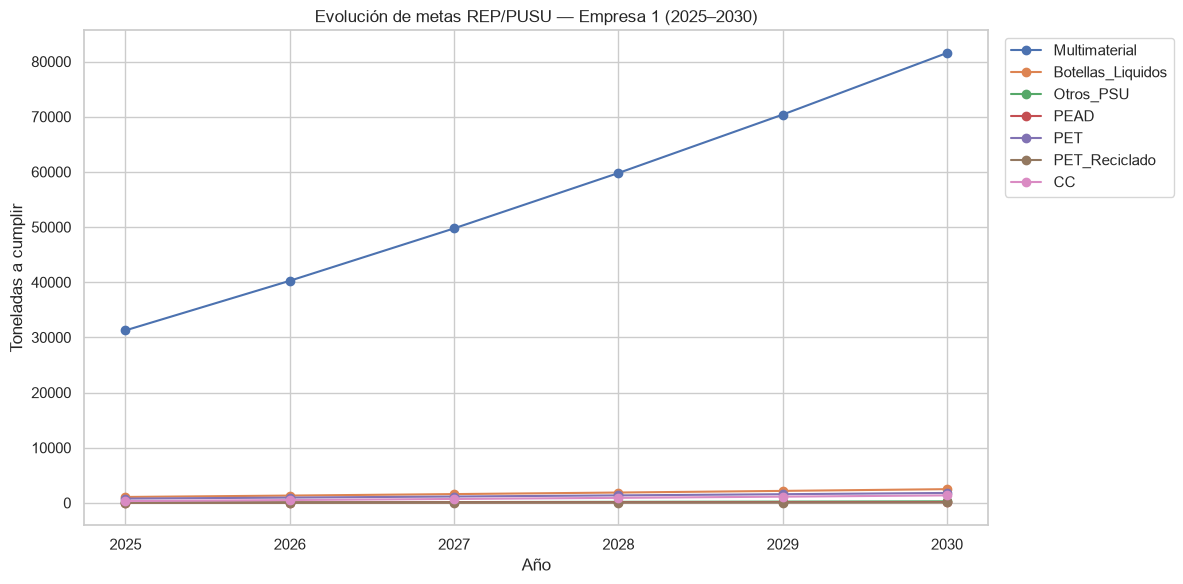

La categoría Multimaterial crece más en términos absolutos por su mayor línea base.
PET y Botellas_Líquidos crecen más rápido en términos relativos (% meta más alto).
Implicación: CEMPRE debe priorizar logística de recolección de PET y plásticos líquidos.


In [22]:
# Gráfico evolución de metas por categoría
fig, ax = plt.subplots(figsize=(12, 6))

for cat in df_metas['Categoría'].unique():
    sub = df_metas[df_metas['Categoría'] == cat]
    ax.plot(sub['Año'], sub['Ton_a_Cumplir'], marker='o', label=cat)

ax.set_title('Evolución de metas REP/PUSU — Empresa 1 (2025–2030)')
ax.set_xlabel('Año')
ax.set_ylabel('Toneladas a cumplir')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig('../datos/metas_rep_pusu.png', dpi=150)
plt.show()
print('La categoría Multimaterial crece más en términos absolutos por su mayor línea base.')
print('PET y Botellas_Líquidos crecen más rápido en términos relativos (% meta más alto).')
print('Implicación: CEMPRE debe priorizar logística de recolección de PET y plásticos líquidos.')

# Parte 3 — Análisis y visualización
## Visualización 1: Evolución anual por origen

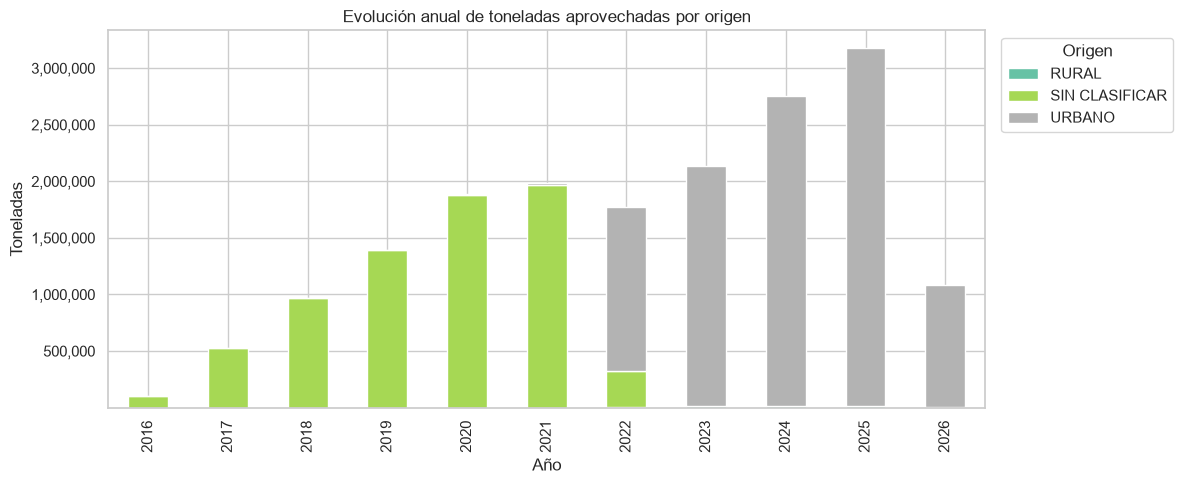

Hallazgo: El origen Urbano domina, pero Sin Clasificar representa ~42% — limitación de reporte.


In [23]:
evol_origen = df_clean.groupby(['AÑO','Origen de los Residuos'])['TONELADAS_NUM'].sum().unstack().fillna(0)

fig, ax = plt.subplots(figsize=(12, 5))
evol_origen.plot(kind='bar', stacked=True, ax=ax, colormap='Set2')
ax.set_title('Evolución anual de toneladas aprovechadas por origen')
ax.set_xlabel('Año')
ax.set_ylabel('Toneladas')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend(title='Origen', bbox_to_anchor=(1.01,1))
plt.tight_layout()
plt.savefig('../datos/viz1_evolucion_origen.png', dpi=150)
plt.show()
print('Hallazgo: El origen Urbano domina, pero Sin Clasificar representa ~42% — limitación de reporte.')

## Visualización 2: Top 10 departamentos — último año completo

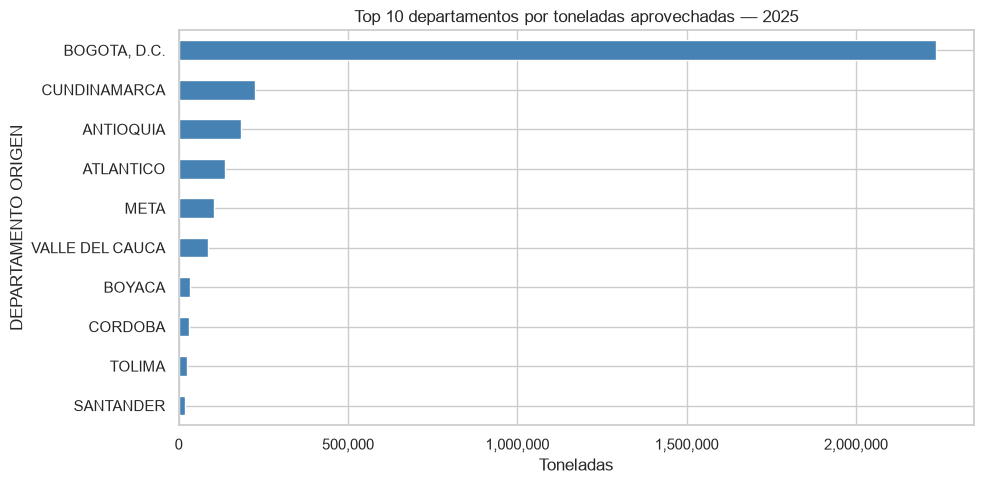

Hallazgo: Alta concentración en Bogotá y Antioquia — refleja densidad urbana y capacidad instalada.


In [24]:
ultimo_año = df_clean['AÑO'].max() - 1  # último año completo
top10_dep = (
    df_clean[df_clean['AÑO'] == ultimo_año]
    .groupby('DEPARTAMENTO ORIGEN')['TONELADAS_NUM']
    .sum().nlargest(10)
)

fig, ax = plt.subplots(figsize=(10, 5))
top10_dep.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title(f'Top 10 departamentos por toneladas aprovechadas — {ultimo_año}')
ax.set_xlabel('Toneladas')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.savefig('../datos/viz2_top10_departamentos.png', dpi=150)
plt.show()
print('Hallazgo: Alta concentración en Bogotá y Antioquia — refleja densidad urbana y capacidad instalada.')

## Visualización 3: Mapa de calor Año × Región

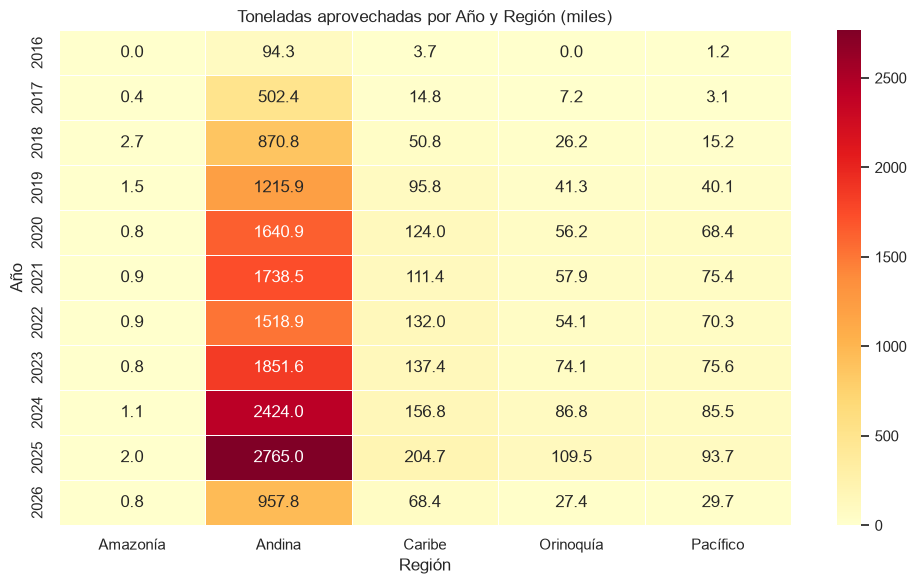

Hallazgo: La región Andina concentra >70% del total nacional en todos los años.


In [25]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(
    pivot_region / 1000,
    annot=True, fmt='.1f', cmap='YlOrRd',
    linewidths=0.5, ax=ax
)
ax.set_title('Toneladas aprovechadas por Año y Región (miles)')
ax.set_xlabel('Región')
ax.set_ylabel('Año')
plt.tight_layout()
plt.savefig('../datos/viz3_heatmap_region.png', dpi=150)
plt.show()
print('Hallazgo: La región Andina concentra >70% del total nacional en todos los años.')

## Visualización 4: Estacionalidad mensual

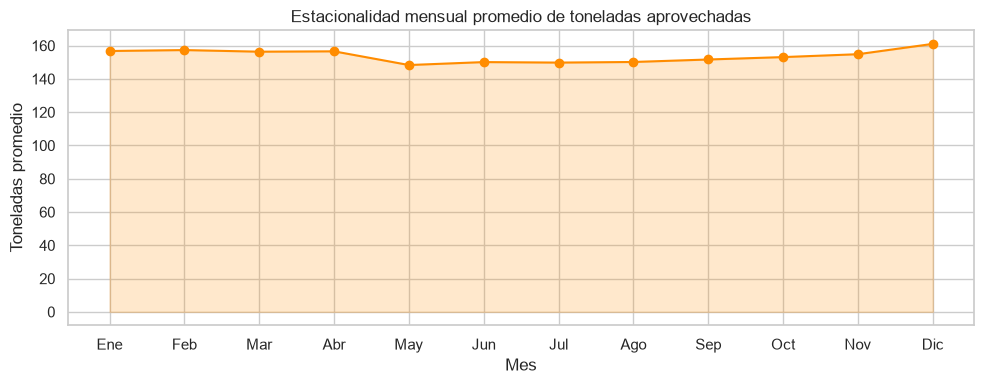

Hallazgo no trivial: Los meses de fin de año (Oct-Dic) muestran picos de reporte,
posiblemente por presión de cierre de metas anuales, no por mayor aprovechamiento real.


In [26]:
estac = df_clean.groupby('MES_NUMERO')['TONELADAS_NUM'].mean()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(estac.index, estac.values, marker='o', color='darkorange')
ax.fill_between(estac.index, estac.values, alpha=0.2, color='darkorange')
ax.set_xticks(range(1,13))
ax.set_xticklabels(['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic'])
ax.set_title('Estacionalidad mensual promedio de toneladas aprovechadas')
ax.set_xlabel('Mes')
ax.set_ylabel('Toneladas promedio')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.savefig('../datos/viz4_estacionalidad.png', dpi=150)
plt.show()
print('Hallazgo no trivial: Los meses de fin de año (Oct-Dic) muestran picos de reporte,')
print('posiblemente por presión de cierre de metas anuales, no por mayor aprovechamiento real.')

## 3.2 Proyección nacional — dos métodos

In [27]:
# Serie histórica anual
serie = df_clean.groupby('AÑO')['TONELADAS_NUM'].sum()
# Último año completo
serie = serie[serie.index <= ultimo_año]

años_hist = serie.index.values.reshape(-1, 1)
ton_hist  = serie.values
años_pred = np.array([ultimo_año+1, ultimo_año+2, ultimo_año+3]).reshape(-1, 1)

# Método 1: Regresión lineal
lr = LinearRegression()
lr.fit(años_hist, ton_hist)
pred_lr = lr.predict(años_pred)

# Método 2: Suavización exponencial (Holt)
modelo_hw = ExponentialSmoothing(ton_hist, trend='add', seasonal=None)
fit_hw    = modelo_hw.fit()
pred_hw   = fit_hw.forecast(3)

# Tabla comparativa
df_proy = pd.DataFrame({
    'Año': años_pred.flatten(),
    'Regresión Lineal': pred_lr.round(0),
    'Suavización Exponencial': pred_hw.round(0)
})
print(df_proy.to_string(index=False))

 Año  Regresión Lineal  Suavización Exponencial
2026         3349774.0                3349774.0
2027         3655068.0                3655067.0
2028         3960361.0                3960361.0


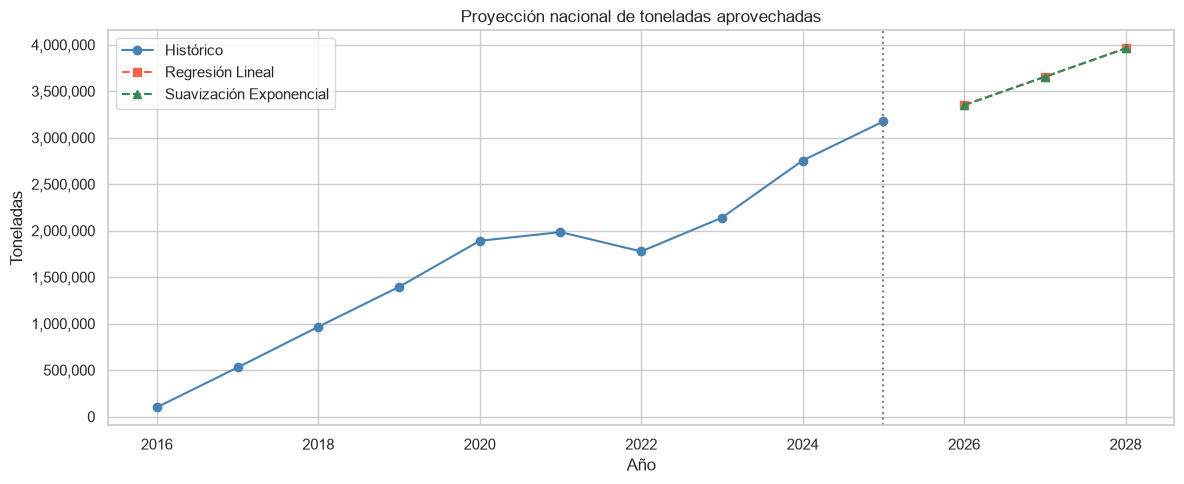

In [28]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(serie.index, ton_hist, marker='o', label='Histórico', color='steelblue')
ax.plot(años_pred.flatten(), pred_lr, marker='s', linestyle='--', label='Regresión Lineal', color='tomato')
ax.plot(años_pred.flatten(), pred_hw, marker='^', linestyle='--', label='Suavización Exponencial', color='seagreen')

ax.axvline(x=ultimo_año, linestyle=':', color='gray')
ax.set_title('Proyección nacional de toneladas aprovechadas')
ax.set_xlabel('Año')
ax.set_ylabel('Toneladas')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.savefig('../datos/viz5_proyeccion.png', dpi=150)
plt.show()

# Parte 5 — Exportación final de datasets

In [29]:
# Exportar tabla de metas consolidada
df_metas.to_csv('../datos/tabla_metas_rep_pusu_empresa1.csv', index=False)
print('Exportaciones completas:')
print('  - dataset_analitico.csv')
print('  - proyeccion_metas_rep.csv')
print('  - tabla_metas_rep_pusu_empresa1.csv')
print('  - dashboard.html')
print('  - viz1 a viz5 (PNG)')

Exportaciones completas:
  - dataset_analitico.csv
  - proyeccion_metas_rep.csv
  - tabla_metas_rep_pusu_empresa1.csv
  - dashboard.html
  - viz1 a viz5 (PNG)
